###1. 지표 뽑아내기

In [ ]:
"""QC metrics extractor for warped bed images (Colab-friendly, simple version)

사용법 (Colab 기준)
1) 아래 INPUT_DIR, OUTPUT_CSV 경로만 수정
2) 셀 실행
→ 끝

- argparse 없음
- 경로 하드코딩
- 재귀 탐색
- 병렬 처리 + 진행률
- 중간중간 CSV 저장 (중단돼도 다시 실행 가능)
"""

from __future__ import annotations

import os
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================
# 🔧 여기만 수정하면 됨
# ============================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images"   # warp된 bed 이미지 폴더
OUTPUT_CSV = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/qc_metrics_warp.csv"
NUM_WORKERS = 4        # Colab CPU 기준 2~4 권장
CHUNK_SIZE = 300       # 몇 장마다 CSV 저장할지
ALSO_HSV = True        # HSV V 채널도 같이 뽑을지
# ============================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def list_images(root: Path):
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS])


def safe_imread(path: str):
    try:
        data = np.fromfile(path, dtype=np.uint8)
        return cv2.imdecode(data, cv2.IMREAD_COLOR)
    except Exception:
        return cv2.imread(path, cv2.IMREAD_COLOR)


def compute_metrics(img_path: Path, root: Path):
    row = {
        "filename": img_path.name,
        "relpath": str(img_path.relative_to(root)).replace("\\", "/"),
        "ok": False,
    }

    img = safe_imread(str(img_path))
    if img is None:
        row["error"] = "imread_failed"
        return row

    h, w = img.shape[:2]
    row["height"] = h
    row["width"] = w

    # ----- LAB (L channel) -----
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0].astype(np.uint8).reshape(-1)

    row.update({
        "mean_L": float(L.mean()),
        "std_L": float(L.std()),
        "p01_L": float(np.percentile(L, 1)),
        "p05_L": float(np.percentile(L, 5)),
        "p50_L": float(np.percentile(L, 50)),
        "p95_L": float(np.percentile(L, 95)),
        "p99_L": float(np.percentile(L, 99)),
        "sat_dark_ratio_L10": float((L < 10).mean()),
        "sat_bright_ratio_L245": float((L > 245).mean()),
    })

    # ----- HSV (V channel, optional) -----
    if ALSO_HSV:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        V = hsv[:, :, 2].astype(np.uint8).reshape(-1)
        row.update({
            "mean_V": float(V.mean()),
            "std_V": float(V.std()),
            "p05_V": float(np.percentile(V, 5)),
            "p50_V": float(np.percentile(V, 50)),
            "p95_V": float(np.percentile(V, 95)),
            "sat_dark_ratio_V10": float((V < 10).mean()),
            "sat_bright_ratio_V245": float((V > 245).mean()),
        })

    row["ok"] = True
    return row


# ============================
# 🚀 실행부
# ============================
root = Path(INPUT_DIR)
assert root.exists(), f"INPUT_DIR not found: {root}"

images = list_images(root)
print(f"[INFO] Found {len(images)} images")

# resume 처리
if Path(OUTPUT_CSV).exists():
    done = set(pd.read_csv(OUTPUT_CSV, usecols=["relpath"])["relpath"].astype(str))
    images = [p for p in images if str(p.relative_to(root)).replace("\\", "/") not in done]
    print(f"[INFO] Resume: remaining {len(images)} images")

start = time.time()
buffer = []

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
    futures = [ex.submit(compute_metrics, p, root) for p in images]

    for i, fut in enumerate(tqdm(as_completed(futures), total=len(futures), desc="QC metrics")):
        buffer.append(fut.result())

        if (i + 1) % CHUNK_SIZE == 0:
            df = pd.DataFrame(buffer)
            df.to_csv(
                OUTPUT_CSV,
                mode="a" if Path(OUTPUT_CSV).exists() else "w",
                header=not Path(OUTPUT_CSV).exists(),
                index=False,
                encoding="utf-8-sig",
            )
            buffer.clear()

# flush
if buffer:
    df = pd.DataFrame(buffer)
    df.to_csv(
        OUTPUT_CSV,
        mode="a" if Path(OUTPUT_CSV).exists() else "w",
        header=not Path(OUTPUT_CSV).exists(),
        index=False,
        encoding="utf-8-sig",
    )

print(f"[DONE] Saved: {OUTPUT_CSV}")
print(f"[TIME] {(time.time() - start)/60:.1f} min")

[INFO] Found 2193 images


QC metrics: 100%|██████████| 2193/2193 [27:10<00:00,  1.34it/s]

[DONE] Saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/qc_metrics_warp.csv
[TIME] 27.2 min


#보정기준 설정 시각화

In [ ]:
df=pd.read_csv("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/qc_metrics_warp.csv")
df.head()

,filename,relpath,ok,height,width,mean_L,std_L,p01_L,p05_L,p50_L,...,p99_L,sat_dark_ratio_L10,sat_bright_ratio_L245,mean_V,std_V,p05_V,p50_V,p95_V,sat_dark_ratio_V10,sat_bright_ratio_V245
0,bed04_20251128_184422_cam2.jpg,251128-251212/251128/bed04_20251128_184422_cam...,True,600,1800,101.872749,44.738869,23.0,36.0,98.0,...,217.0,0.000188,0.000978,100.124525,42.918921,40.0,95.0,178.0,0.000043,0.001152
1,bed02_20251128_214427_cam2.jpg,251128-251212/251128/bed02_20251128_214427_cam...,True,600,1800,99.221595,47.588734,16.0,27.0,95.0,...,212.0,0.000567,0.000487,98.251581,45.439642,32.0,92.0,178.0,0.000017,0.000547
2,bed01_20251128_183832_cam2.jpg,251128-251212/251128/bed01_20251128_183832_cam...,True,600,1800,100.315966,45.402079,18.0,30.0,98.0,...,218.0,0.000939,0.001959,99.112421,43.492111,34.0,95.0,174.0,0.000033,0.002573
3,bed03_20251128_184224_cam2.jpg,251128-251212/251128/bed03_20251128_184224_cam...,True,600,1800,105.128758,47.815692,19.0,33.0,100.0,...,224.0,0.001617,0.001831,103.506307,46.209872,37.0,97.0,188.0,0.000354,0.002494
4,bed06_20251128_184013_cam2.jpg,251128-251212/251128/bed06_20251128_184013_cam...,True,600,1800,98.752171,47.544950,16.0,27.0,94.0,...,211.0,0.000494,0.000444,97.799920,45.420221,32.0,91.0,178.0,0.000006,0.000492


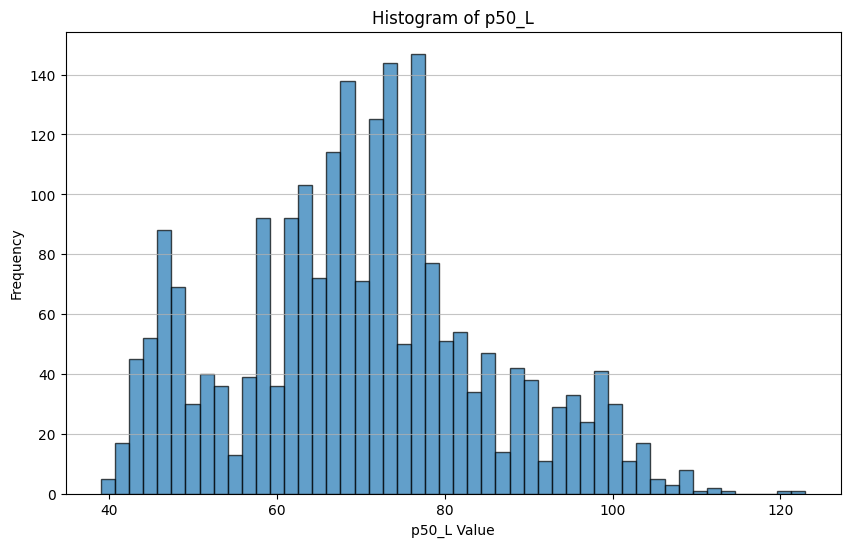

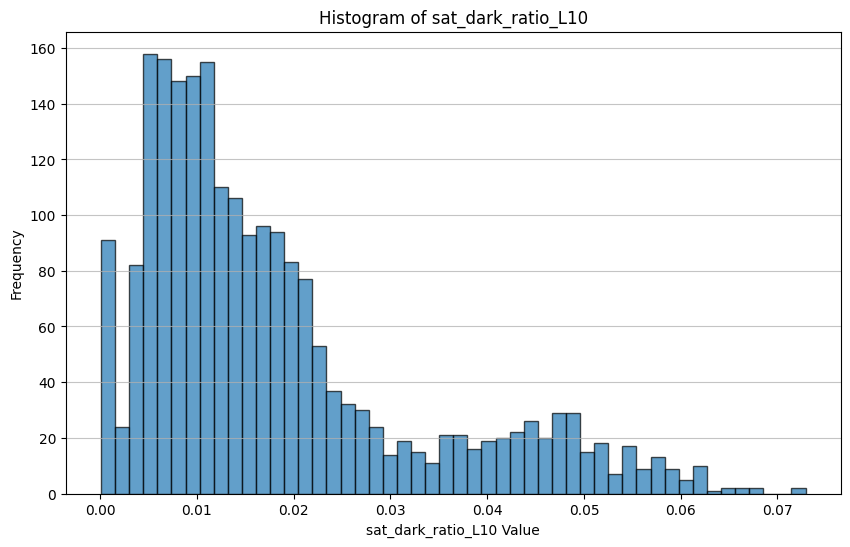

In [ ]:
p50_L_bins = [40, 60, 80, 90, 110]
p50_L_labels = ['Very Dark', 'Dark', 'Medium', 'Bright', 'Very Bright']

print(f"p50_L_bins: {p50_L_bins}")
print(f"p50_L_labels: {p50_L_labels}")

p50_L_bins: [0, 40, 60, 80, 90, 110]
p50_L_labels: ['Very Dark', 'Dark', 'Medium', 'Bright', 'Very Bright']


In [ ]:
df['p50_L_bin_label'] = pd.cut(df['p50_L'], bins=p50_L_bins, labels=p50_L_labels, right=False)
df.head()

,filename,relpath,ok,height,width,mean_L,std_L,p01_L,p05_L,p50_L,...,sat_dark_ratio_L10,sat_bright_ratio_L245,mean_V,std_V,p05_V,p50_V,p95_V,sat_dark_ratio_V10,sat_bright_ratio_V245,p50_L_bin_label
0,bed04_20251128_184422_cam2.jpg,251128-251212/251128/bed04_20251128_184422_cam...,True,600,1800,101.872749,44.738869,23.0,36.0,98.0,...,0.000188,0.000978,100.124525,42.918921,40.0,95.0,178.0,0.000043,0.001152,Very Bright
1,bed02_20251128_214427_cam2.jpg,251128-251212/251128/bed02_20251128_214427_cam...,True,600,1800,99.221595,47.588734,16.0,27.0,95.0,...,0.000567,0.000487,98.251581,45.439642,32.0,92.0,178.0,0.000017,0.000547,Very Bright
2,bed01_20251128_183832_cam2.jpg,251128-251212/251128/bed01_20251128_183832_cam...,True,600,1800,100.315966,45.402079,18.0,30.0,98.0,...,0.000939,0.001959,99.112421,43.492111,34.0,95.0,174.0,0.000033,0.002573,Very Bright
3,bed03_20251128_184224_cam2.jpg,251128-251212/251128/bed03_20251128_184224_cam...,True,600,1800,105.128758,47.815692,19.0,33.0,100.0,...,0.001617,0.001831,103.506307,46.209872,37.0,97.0,188.0,0.000354,0.002494,Very Bright
4,bed06_20251128_184013_cam2.jpg,251128-251212/251128/bed06_20251128_184013_cam...,True,600,1800,98.752171,47.544950,16.0,27.0,94.0,...,0.000494,0.000444,97.799920,45.420221,32.0,91.0,178.0,0.000006,0.000492,Very Bright


In [ ]:
representative_images_df = df.groupby('p50_L_bin_label', observed=True).sample(n=1, random_state=42)
print(representative_images_df[['p50_L_bin_label', 'filename', 'p50_L']])

     p50_L_bin_label                        filename  p50_L
693        Very Dark  bed19_20251206_062402_cam2.jpg   39.0
1562            Dark  bed28_20251217_062303_cam2.jpg   45.0
1071          Medium  bed47_20251210_080726_cam2.jpg   63.0
390           Bright  bed81_20251202_062130_cam2.jpg   88.0
168      Very Bright  bed19_20251130_114352_cam2.jpg   96.0


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

plt.figure(figsize=(15, 5 * len(representative_images_df)))

for i, (index, row) in enumerate(representative_images_df.iterrows()):
    image_path = os.path.join(INPUT_DIR, row['relpath'])
    img = cv2.imread(image_path)

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(len(representative_images_df), 1, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{row['p50_L_bin_label']}: p50_L = {row['p50_L']:.1f}")
        plt.axis('off')
    else:
        print(f"Warning: Could not read image {image_path}")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 구간별로 보정 전후를 출력하기

In [ ]:
"""Warp bed 밝기 보정 샘플 비교 (Colab용)

목표
- qc_metrics_warp.csv(또는 네 QC CSV)에서 p50_L 구간별로 대표 이미지 1장씩 랜덤 샘플
- 각 이미지에 대해 (원본 vs 보정후) 비교 이미지를 저장/표시

주의
- 지금 단계는 'bed 전체 warp 이미지' 기준 보정.
- CLAHE는 여기서 금지(원본 질감/경계 튐 위험). Gamma만 적용.

사용법
1) 아래 INPUT_DIR / QC_CSV / OUT_DIR 수정
2) 셀 실행
3) OUT_DIR에 각 구간별 before_after 이미지 저장됨

"""

from __future__ import annotations

import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

# ============================
# 🔧 여기만 수정
# ============================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 전"          # warp bed 이미지 폴더
QC_CSV = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/qc_metrics_warp.csv" # QC 지표 CSV
OUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/qc전후image"   # 결과 저장 폴더
RANDOM_STATE = 42
# ============================

# ----------------------------
# 구간 설정 (네가 쓰던 방식 유지)
# ----------------------------
p50_L_bins = [0, 40, 60, 80, 90, 110]
p50_L_labels = ['Very Dark', 'Dark', 'Medium', 'Bright', 'Very Bright']


In [ ]:

# ----------------------------
# 보정 규칙 (우리가 합의한 기준을 이 bins에 매핑)
# - <45는 drop 권장이라 원칙상 제외
# - Dark(60미만)는 강한 gamma
# - Medium은 중간 gamma
# - Bright/Very Bright는 보정 없음
# ----------------------------
GAMMA_BY_LABEL = {
    'Very Dark': None,  # DROP(원칙). 그래도 미리보기는 원본만 저장.
    'Dark': 1.8,        # 40~60 구간
    'Medium': 1.4,      # 60~80 구간
    'Bright': None,     # 80~90 구간
    'Very Bright': None # 90~110 구간
}


def safe_imread(path: str):
    # Colab/Drive에서 일반 cv2.imread도 대체로 OK. 그래도 안정적으로.
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    return img


def apply_gamma_bgr(img_bgr: np.ndarray, gamma: float) -> np.ndarray:
    """Gamma correction on LAB-L channel (more stable for color)."""
    if gamma is None:
        return img_bgr

    # BGR -> LAB
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    # Normalize L to [0,1] then gamma
    Lf = L.astype(np.float32) / 255.0
    Lg = np.power(Lf, 1.0 / gamma)  # gamma>1 => brighten
    L2 = np.clip(Lg * 255.0, 0, 255).astype(np.uint8)

    lab2 = cv2.merge([L2, A, B])
    out = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)
    return out


def make_side_by_side(before_bgr: np.ndarray, after_bgr: np.ndarray) -> np.ndarray:
    if after_bgr is None:
        after_bgr = before_bgr

    # 높이 맞추기
    h = min(before_bgr.shape[0], after_bgr.shape[0])
    if before_bgr.shape[0] != h:
        scale = h / before_bgr.shape[0]
        before_bgr = cv2.resize(before_bgr, (int(before_bgr.shape[1]*scale), h), interpolation=cv2.INTER_AREA)
    if after_bgr.shape[0] != h:
        scale = h / after_bgr.shape[0]
        after_bgr = cv2.resize(after_bgr, (int(after_bgr.shape[1]*scale), h), interpolation=cv2.INTER_AREA)

    return np.hstack([before_bgr, after_bgr])


def put_label(img_bgr: np.ndarray, text: str) -> np.ndarray:
    out = img_bgr.copy()
    # 상단 좌측 라벨
    cv2.putText(out, text, (12, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 0), 5, cv2.LINE_AA)
    cv2.putText(out, text, (12, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 255), 2, cv2.LINE_AA)
    return out


# ============================
# 🚀 실행
# ============================
input_dir = Path(INPUT_DIR)
out_dir = Path(OUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

assert Path(QC_CSV).exists(), f"QC_CSV not found: {QC_CSV}"
df = pd.read_csv(QC_CSV)

# relpath 기반으로 실제 파일경로 만들기
# (CSV에 relpath가 있고, INPUT_DIR 기준 상대경로라고 가정)
df["abs_path"] = df["relpath"].apply(lambda p: str(input_dir / str(p)))

# 유효 이미지(존재)만
exists_mask = df["abs_path"].apply(lambda p: Path(p).exists())
df = df[exists_mask].copy()

# bin 라벨 생성
# right=False => [40,60) 형태 (네 코드 유지)
df['p50_L_bin_label'] = pd.cut(df['p50_L'], bins=p50_L_bins, labels=p50_L_labels, right=False)

# 각 구간에서 1장 샘플
rep = df.groupby('p50_L_bin_label', observed=True).sample(n=1, random_state=RANDOM_STATE)

print("[INFO] Selected representative images:")
print(rep[["p50_L_bin_label", "filename", "p50_L", "p05_L", "sat_dark_ratio_L10", "abs_path"]])

for _, r in rep.iterrows():
    label = str(r["p50_L_bin_label"])
    p50 = float(r["p50_L"])
    img_path = str(r["abs_path"])

    img = safe_imread(img_path)
    if img is None:
        print(f"[WARN] imread failed: {img_path}")
        continue

    gamma = GAMMA_BY_LABEL.get(label, None)

    # 규칙상 Very Dark는 drop 권장
    if label == "Very Dark":
        after = None
        rule_txt = f"{label} (p50={p50:.1f}) | DROP recommended"
    else:
        after = apply_gamma_bgr(img, gamma) if gamma else img
        if gamma:
            rule_txt = f"{label} (p50={p50:.1f}) | gamma={gamma}"
        else:
            rule_txt = f"{label} (p50={p50:.1f}) | no correction"

    comp = make_side_by_side(img, after)
    comp = put_label(comp, rule_txt)

    out_name = f"preview_{label}_p50_{p50:.1f}.jpg".replace(" ", "_")
    out_path = out_dir / out_name
    cv2.imwrite(str(out_path), comp)

print(f"[DONE] Saved previews to: {out_dir}")

# Colab에서 바로 보려면 아래 2줄 사용
try:
    from google.colab.patches import cv2_imshow
    # 최신 저장된 파일들 몇 개 보여주기
    for p in sorted(out_dir.glob("preview_*.jpg")):
        img = cv2.imread(str(p))
        print(p.name)
        cv2_imshow(img)
except Exception:
    pass


Output hidden; open in https://colab.research.google.com to view.

###전체 이미지에 대해서 보정하기

In [25]:
"""Warp bed 이미지 2,193장 밝기 보정 적용 (Colab/로컬 겸용)

요구사항 반영
- INPUT_DIR 하위폴더 재귀 탐색(= QC CSV의 relpath 기반)
- QC 기준(p50_L)으로 보정 규칙 적용
- 출력은 OUT_DIR에 '동일한 하위폴더 구조'로 저장
- 병렬 처리 + 진행률/ETA
- 중간에 꺼져도 재시작 가능(이미 저장된 파일은 skip)
- 안전 저장: 임시파일(.tmp)로 저장 후 rename

규칙(확정)
- p50_L < 45  : DROP (저장하지 않고 drop 목록에 기록)
- 45 <= p50_L < 60 : gamma=1.8
- 60 <= p50_L < 80 : gamma=1.4
- p50_L >= 80 : no correction (원본 그대로 복사 저장)

입력
- QC_CSV: qc_metrics_warp.csv (필수 컬럼: relpath, p50_L)

출력
- OUT_DIR/ (보정 또는 복사된 이미지)
- OUT_DIR/_logs/process_log.csv (처리 결과 누적)
- OUT_DIR/_logs/dropped.csv (drop 목록)

"""

from __future__ import annotations

import os
import time
import csv
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================
# 🔧 여기만 수정 (Colab 기준)
# ============================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 전"                # 원본 warp-bed 폴더
QC_CSV    = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/qc_metrics_warp.csv"     # QC 지표 CSV
OUT_DIR   = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 후"      # 보정 결과 폴더
NUM_WORKERS = 6                                               # Colab은 4~8 권장
# ============================

# 처리 옵션
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
WRITE_JPEG_QUALITY = 95

In [26]:
# ----------------------------
# 규칙 함수
# ----------------------------

def get_action_and_gamma(p50: float):
    """return (action, gamma)
    action: 'drop' | 'copy' | 'gamma'
    """
    if p50 < 38:
        return "drop", None
    if p50 < 60:
        return "gamma", 1.8
    if p50 < 80:
        return "gamma", 1.4
    return "copy", None


def apply_gamma_on_LAB_L(img_bgr: np.ndarray, gamma: float) -> np.ndarray:
    """Gamma correction on LAB L-channel."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    Lf = L.astype(np.float32) / 255.0
    Lg = np.power(Lf, 1.0 / gamma)  # gamma>1 brightens
    L2 = np.clip(Lg * 255.0, 0, 255).astype(np.uint8)

    lab2 = cv2.merge([L2, A, B])
    out = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)
    return out


def imread_safe(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    return img


def ensure_parent(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)


def atomic_write_image(out_path: Path, img_bgr: np.ndarray):
    """Write image safely.

    NOTE:
    - OpenCV는 확장자로 writer를 고른다. 입력 relpath에
      .JPG/.jpg/.png 외의 확장자(또는 확장자 없음)가 섞이면 imwrite가 실패할 수 있음.
    - 따라서 저장 시점에 확장자를 강제로 .jpg로 통일한다.
    - Google Drive에서 대량 처리 시 tmp-rename이 오히려 문제를 만들 수 있어,
      요청대로 '임시파일 없이' 직접 저장한다.
    """
    # 확장자 강제 통일
    if out_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        out_path = out_path.with_suffix(".jpg")

    ensure_parent(out_path)

    ext = out_path.suffix.lower()
    params = []
    if ext in {".jpg", ".jpeg"}:
        params = [int(cv2.IMWRITE_JPEG_QUALITY), int(WRITE_JPEG_QUALITY)]

    ok = cv2.imwrite(str(out_path), img_bgr, params)
    if not ok:
        raise RuntimeError(f"cv2.imwrite failed for: {out_path}")


def atomic_copy(src: Path, dst: Path):
    # copy는 원본 확장자 그대로 유지(단, dst 확장자 불명확하면 .jpg로 강제)
    if dst.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        dst = dst.with_suffix(".jpg")

    ensure_parent(dst)
    shutil.copy2(src, dst)


# ----------------------------(src: Path, dst: Path):
    ensure_parent(dst)
    tmp = dst.with_suffix(dst.suffix + ".tmp")
    if tmp.exists():
        tmp.unlink()
    shutil.copy2(src, tmp)
    if dst.exists():
        dst.unlink()
    tmp.rename(dst)


# ----------------------------
# 로그/리줌
# ----------------------------

def load_done_set(log_path: Path) -> set[str]:
    """이미 처리된 relpath 집합."""
    done = set()
    if not log_path.exists():
        return done
    try:
        df = pd.read_csv(log_path)
        if "relpath" in df.columns:
            done = set(df["relpath"].astype(str).tolist())
    except Exception:
        pass
    return done


def append_row(csv_path: Path, header: list[str], row: dict):
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    write_header = not csv_path.exists()
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=header)
        if write_header:
            w.writeheader()
        w.writerow(row)


# ============================
# 🚀 메인
# ============================

input_dir = Path(INPUT_DIR)
out_dir = Path(OUT_DIR)
logs_dir = out_dir / "_logs"
logs_dir.mkdir(parents=True, exist_ok=True)

process_log = logs_dir / "process_log.csv"
dropped_log = logs_dir / "dropped.csv"

assert Path(QC_CSV).exists(), f"QC CSV not found: {QC_CSV}"
df = pd.read_csv(QC_CSV)

required_cols = {"relpath", "p50_L"}
missing = required_cols - set(df.columns)
assert not missing, f"QC CSV missing columns: {missing}"

df["relpath"] = df["relpath"].astype(str)

# 이미 처리된 파일은 스킵
DONE = load_done_set(process_log)

# 실제 존재하는 파일만
abs_paths = df["relpath"].apply(lambda p: input_dir / p)
exists_mask = abs_paths.apply(lambda p: p.exists())
df = df[exists_mask].copy()
df["abs_path"] = abs_paths[exists_mask].astype(str)

# 스킵 적용
if DONE:
    df = df[~df["relpath"].isin(DONE)].copy()

n_total = len(df)
print(f"[INFO] Remaining to process: {n_total}")
print(f"[INFO] Output dir: {out_dir}")

log_header = ["relpath", "p50_L", "action", "gamma", "status", "message", "out_relpath", "elapsed_sec"]
drop_header = ["relpath", "p50_L", "reason"]


def process_one(row: pd.Series):
    t0 = time.time()

    relpath = str(row["relpath"])
    p50 = float(row["p50_L"])

    src = input_dir / relpath

    # 출력 확장자 유지
    dst = out_dir / relpath

    # 이미 결과 파일이 있으면 스킵(추가 안전)
    if dst.exists():
        return {
            "relpath": relpath,
            "p50_L": p50,
            "action": "skip",
            "gamma": "",
            "status": "ok",
            "message": "already exists",
            "out_relpath": relpath,
            "elapsed_sec": round(time.time() - t0, 4),
            "_dropped": False,
            "_drop_reason": "",
        }

    action, gamma = get_action_and_gamma(p50)

    if action == "drop":
        return {
            "relpath": relpath,
            "p50_L": p50,
            "action": "drop",
            "gamma": "",
            "status": "ok",
            "message": "dropped by rule (p50<45)",
            "out_relpath": "",
            "elapsed_sec": round(time.time() - t0, 4),
            "_dropped": True,
            "_drop_reason": "p50<45",
        }

    if action == "copy":
        # 원본 그대로 복사
        atomic_copy(src, dst)
        return {
            "relpath": relpath,
            "p50_L": p50,
            "action": "copy",
            "gamma": "",
            "status": "ok",
            "message": "copied",
            "out_relpath": relpath,
            "elapsed_sec": round(time.time() - t0, 4),
            "_dropped": False,
            "_drop_reason": "",
        }

    # gamma 보정
    img = imread_safe(src)
    if img is None:
        raise RuntimeError("imread failed")

    out_img = apply_gamma_on_LAB_L(img, gamma)
    atomic_write_image(dst, out_img)

    return {
        "relpath": relpath,
        "p50_L": p50,
        "action": "gamma",
        "gamma": gamma,
        "status": "ok",
        "message": "gamma applied",
        "out_relpath": relpath,
        "elapsed_sec": round(time.time() - t0, 4),
        "_dropped": False,
        "_drop_reason": "",
    }


if n_total == 0:
    print("[DONE] Nothing to process.")
else:
    # 병렬 실행
    futures = []
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
        for _, r in df.iterrows():
            futures.append(ex.submit(process_one, r))

        with tqdm(total=len(futures), desc="Correcting", unit="img") as pbar:
            for fut in as_completed(futures):
                try:
                    res = fut.result()
                    append_row(process_log, log_header, {
                        "relpath": res["relpath"],
                        "p50_L": res["p50_L"],
                        "action": res["action"],
                        "gamma": res["gamma"],
                        "status": res["status"],
                        "message": res["message"],
                        "out_relpath": res["out_relpath"],
                        "elapsed_sec": res["elapsed_sec"],
                    })
                    if res.get("_dropped", False):
                        append_row(dropped_log, drop_header, {
                            "relpath": res["relpath"],
                            "p50_L": res["p50_L"],
                            "reason": res.get("_drop_reason", ""),
                        })
                except Exception as e:
                    # 에러도 로그 남기고 계속
                    append_row(process_log, log_header, {
                        "relpath": "",
                        "p50_L": "",
                        "action": "",
                        "gamma": "",
                        "status": "error",
                        "message": repr(e),
                        "out_relpath": "",
                        "elapsed_sec": "",
                    })
                finally:
                    pbar.update(1)

    print("[DONE] Finished.")
    print(f"- Output: {out_dir}")
    print(f"- Log: {process_log}")
    print(f"- Dropped: {dropped_log}")


[INFO] Remaining to process: 1695
[INFO] Output dir: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 후


Correcting: 100%|██████████| 1695/1695 [00:38<00:00, 44.25img/s]

[DONE] Finished.
- Output: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 후
- Log: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 후/_logs/process_log.csv
- Dropped: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/ROI_WARP/step6_warp_images/보정 후/_logs/dropped.csv
